In [ ]:
import json
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json
from datetime import datetime

file_path2 = "/content/drive/MyDrive/predata0326/finalfinal.json"

with open(file_path2, 'r', encoding='utf-8') as f:
    data = json.load(f)

In [ ]:
import json
from datetime import datetime

# Initialize counters
total_posts = 0
total_retweets = 0
total_users = set()
before_posts = 0
after_posts = 0
before_retweets = 0
after_retweets = 0

# Define the event divider date (e.g., George Floyd death)
divider_date = datetime(2020, 5, 25)

for tweet in data:
    try:
        created_at = tweet.get("createdAt")
        author = tweet.get("author", {}).get("userName")
        retweeters = tweet.get("retweeters", [])

        # Parse creation time
        dt = datetime.strptime(' '.join(created_at.split(' ')[:-2]) + ' ' + created_at.split(' ')[-1], "%a %b %d %H:%M:%S %Y")
        total_posts += 1
        total_retweets += len(retweeters)

        # Track unique users (authors and retweeters)
        if author:
            total_users.add(author)
        for r in retweeters:
            if "screen_name" in r:
                total_users.add(r["screen_name"])

        # Count pre-/post-event posts and retweets
        if dt < divider_date:
            before_posts += 1
            before_retweets += len(retweeters)
        else:
            after_posts += 1
            after_retweets += len(retweeters)

    except Exception:
        continue

# Print summary
print("===== Summary Statistics =====")
print(f"Total posts collected: {total_posts:,}")
print(f"Total retweets: {total_retweets:,}")
print(f"Estimated reach (unique users): {len(total_users):,}")
print(f"Posts BEFORE May 25: {before_posts:,}")
print(f"Retweets BEFORE May 25: {before_retweets:,}")
print(f"Posts ON/AFTER May 25: {after_posts:,}")
print(f"Retweets ON/AFTER May 25: {after_retweets:,}")


===== Summary Statistics =====
Total posts collected: 140,414
Total retweets: 5,860,563
Estimated reach (unique users): 2,329,412
Posts BEFORE May 25: 8,458
Retweets BEFORE May 25: 232,084
Posts ON/AFTER May 25: 131,956
Retweets ON/AFTER May 25: 5,628,479


#Time Range

In [ ]:
# Extract all timestamp fields
time_list = []
for item in data:
    time_str = item.get("createdAt")
    if time_str:
        try:
            dt = datetime.strptime(time_str, "%a %b %d %H:%M:%S %z %Y")
            time_list.append(dt)
        except Exception as e:
            print(f"Failed to parse timestamp: {time_str} → {e}")

# Calculate time range
if time_list:
    start = min(time_list)
    end = max(time_list)
    print("Time Range of Tweets:")
    print(f"Start time: {start.strftime('%Y-%m-%d %H:%M:%S %Z')}")
    print(f"End time: {end.strftime('%Y-%m-%d %H:%M:%S %Z')}")
else:
    print("No valid timestamp found.")

Time Range of Tweets:
Start time: 2019-05-01 01:14:08 UTC
End time: 2021-04-30 23:42:56 UTC


#Post Distribution

Monthly Tweet Counts:
2019-05: 650
2019-06: 698
2019-07: 163
2019-08: 715
2019-09: 604
2019-10: 693
2019-11: 597
2019-12: 657
2020-01: 648
2020-02: 731
2020-03: 698
2020-04: 699
2020-05: 5161
2020-06: 63320
2020-07: 18829
2020-08: 11289
2020-09: 6201
2020-10: 5590
2020-11: 3998
2020-12: 3163
2021-01: 5513
2021-02: 2977
2021-03: 2941
2021-04: 3879


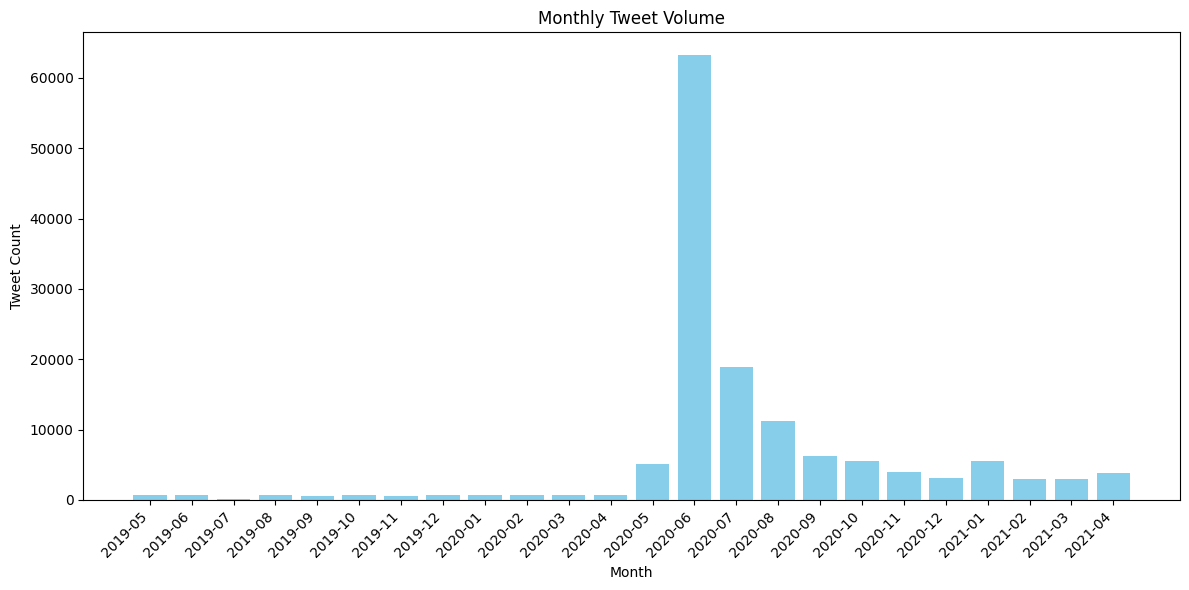

In [ ]:
import json
from collections import defaultdict
import matplotlib.pyplot as plt

# Initialize counters
monthly_count = defaultdict(int)
daily_count_by_month = defaultdict(lambda: defaultdict(int))

# Iterate and count
for item in data:
    time_str = item.get("createdAt")
    if time_str:
        try:
            dt = datetime.strptime(time_str, "%a %b %d %H:%M:%S %z %Y")
            month_key = dt.strftime("%Y-%m")
            day_key = dt.strftime("%Y-%m-%d")
            monthly_count[month_key] += 1
            daily_count_by_month[month_key][day_key] += 1
        except Exception as e:
            continue  # Skip parsing errors

# Display tweet count per month
print("Monthly Tweet Counts:")
for month in sorted(monthly_count):
    print(f"{month}: {monthly_count[month]}")

months = sorted(monthly_count.keys())
counts = [monthly_count[m] for m in months]

plt.figure(figsize=(12, 6))
plt.bar(months, counts, color="skyblue")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Month")
plt.ylabel("Tweet Count")
plt.title("Monthly Tweet Volume")
plt.tight_layout()
plt.show()


#Question1: What role does emotional intensity play before and after the ‘Murder of George Floyd’ incident?

#Q1.1.Difference in emotional intensity before and after the incident

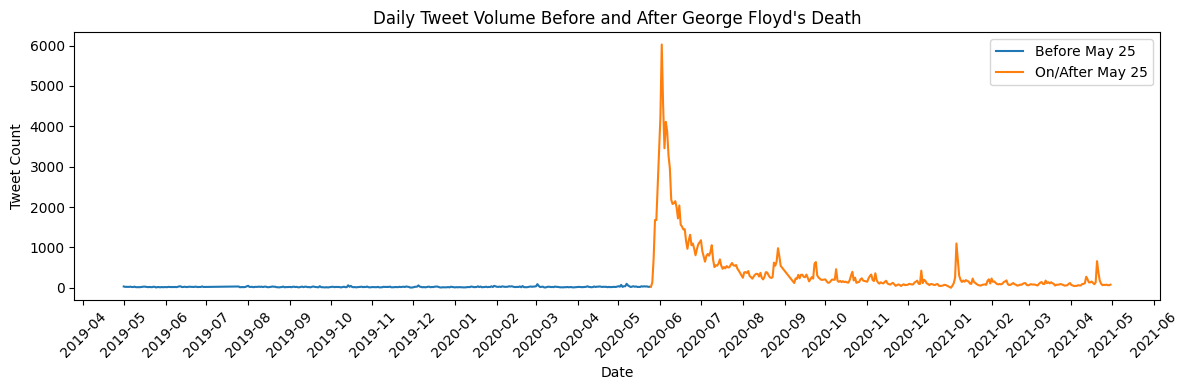

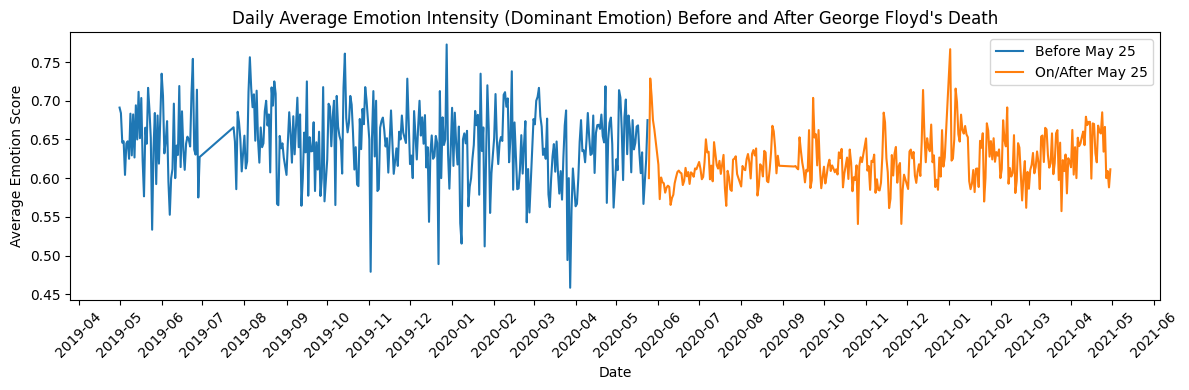

In [ ]:
import json
from datetime import datetime
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter


# Define divider date: George Floyd's death
divider_date = datetime(2020, 5, 25)

# Initialize daily counters
daily_post_count = defaultdict(int)
daily_emotion_score = defaultdict(list)

# Process each tweet
for item in data:
    time_str = item.get("createdAt")
    emotion_data = item.get("emotion_analysis")

    if time_str and emotion_data:
        try:
            dt = datetime.strptime(time_str, "%a %b %d %H:%M:%S %z %Y")
            day_key = dt.strftime("%Y-%m-%d")

            # Use the dominant emotion's score
            dom = emotion_data.get("dominant_emotion")
            score = emotion_data.get("emotions", {}).get(dom, None)

            if score is not None:
                daily_post_count[day_key] += 1
                daily_emotion_score[day_key].append(score)

        except Exception:
            continue

# Compute average emotion score per day
avg_emotion_score = {
    day: sum(scores) / len(scores)
    for day, scores in daily_emotion_score.items()
}

# Sort days
sorted_days = sorted(daily_post_count.keys())
sorted_days_dt = [datetime.strptime(day, "%Y-%m-%d") for day in sorted_days]

post_counts = [daily_post_count[day] for day in sorted_days]
emotion_scores = [avg_emotion_score.get(day, 0) for day in sorted_days]

# Split before and after divider date
before_idx = [i for i, d in enumerate(sorted_days_dt) if d < divider_date]
after_idx = [i for i, d in enumerate(sorted_days_dt) if d >= divider_date]

# Plot 1: Daily post count
plt.figure(figsize=(12, 4))
plt.plot([sorted_days_dt[i] for i in before_idx], [post_counts[i] for i in before_idx], label="Before May 25")
plt.plot([sorted_days_dt[i] for i in after_idx], [post_counts[i] for i in after_idx], label="On/After May 25")
plt.title("Daily Tweet Volume Before and After George Floyd's Death")
plt.xlabel("Date")
plt.ylabel("Tweet Count")
plt.gca().xaxis.set_major_locator(MonthLocator())
plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Daily average emotion intensity
plt.figure(figsize=(12, 4))
plt.plot([sorted_days_dt[i] for i in before_idx], [emotion_scores[i] for i in before_idx], label="Before May 25")
plt.plot([sorted_days_dt[i] for i in after_idx], [emotion_scores[i] for i in after_idx], label="On/After May 25")
plt.title("Daily Average Emotion Intensity (Dominant Emotion) Before and After George Floyd's Death")
plt.xlabel("Date")
plt.ylabel("Average Emotion Score")
plt.gca().xaxis.set_major_locator(MonthLocator())
plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


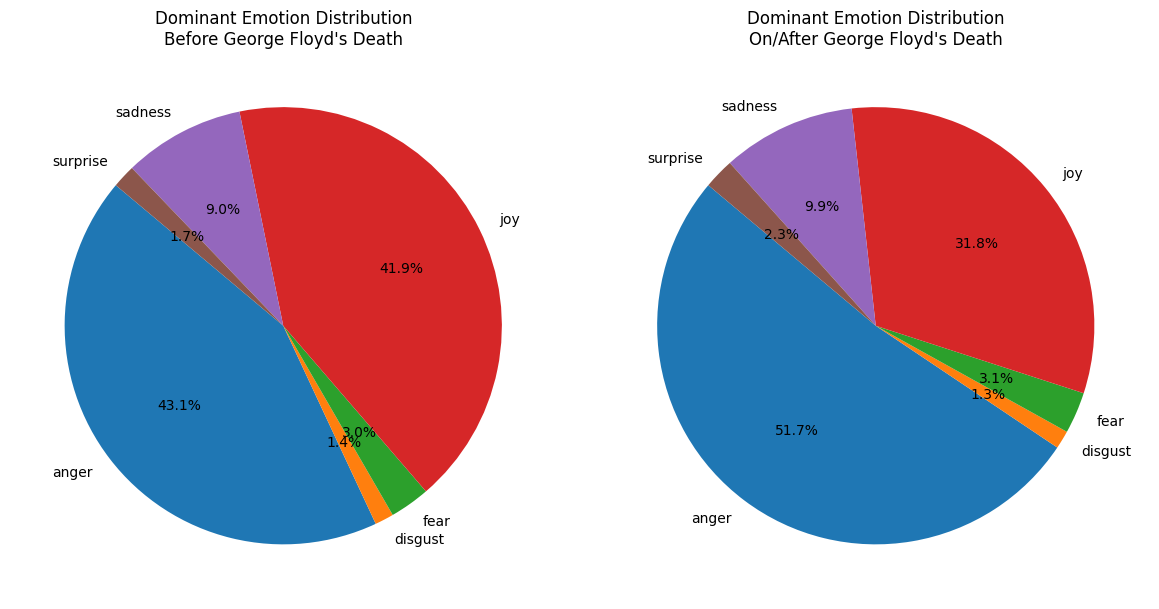

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# Step 1: Count dominant emotions before and after
before_counter = Counter()
after_counter = Counter()

for tweet in data:
    try:
        created_at = tweet.get("createdAt")
        emotion_data = tweet.get("emotion_analysis", {})
        dom_emotion = emotion_data.get("dominant_emotion")

        if not (created_at and dom_emotion):
            continue

        # Remove timezone and parse
        created_at_clean = ' '.join(created_at.split(' ')[:-2]) + ' ' + created_at.split(' ')[-1]
        dt = datetime.strptime(created_at_clean, "%a %b %d %H:%M:%S %Y")

        if dt < datetime(2020, 5, 25):
            before_counter[dom_emotion] += 1
        else:
            after_counter[dom_emotion] += 1
    except:
        continue

# Step 2: Ensure all emotions are present
emotion_types = ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']
for e in emotion_types:
    before_counter.setdefault(e, 0)
    after_counter.setdefault(e, 0)

before_values = [before_counter[e] for e in emotion_types]
after_values = [after_counter[e] for e in emotion_types]

# Step 3: Plot pie charts
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].pie(before_values, labels=emotion_types, autopct='%1.1f%%', startangle=140)
axes[0].set_title("Dominant Emotion Distribution\nBefore George Floyd's Death")

axes[1].pie(after_values, labels=emotion_types, autopct='%1.1f%%', startangle=140)
axes[1].set_title("Dominant Emotion Distribution\nOn/After George Floyd's Death")

plt.tight_layout()
plt.show()


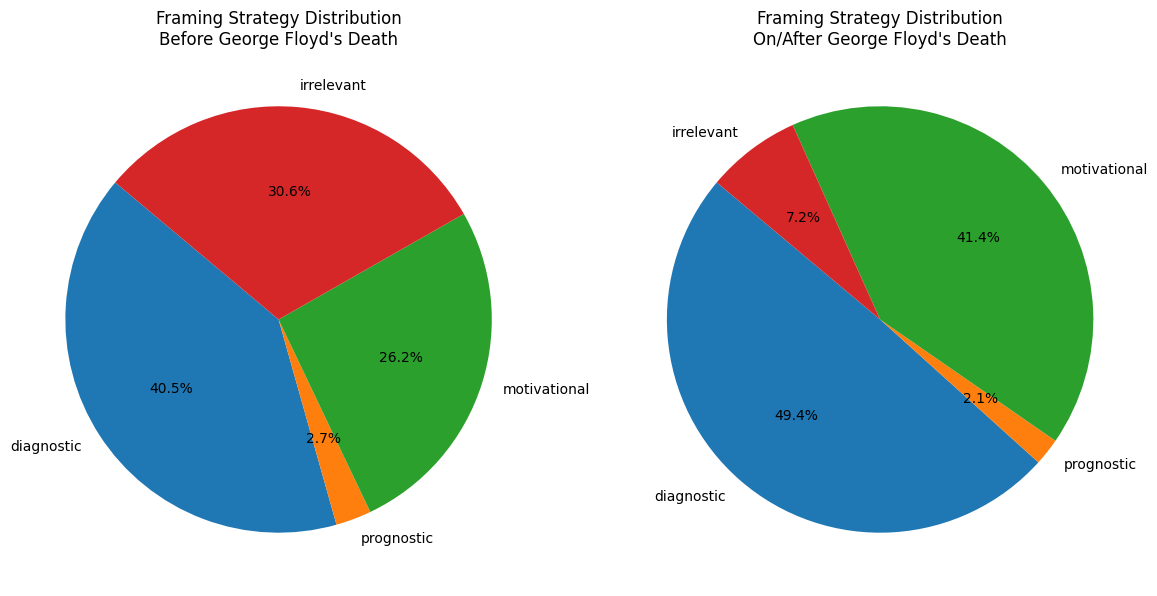

In [ ]:
from collections import Counter
from datetime import datetime
import matplotlib.pyplot as plt

# Step 1: Count framing strategies before and after
before_counter = Counter()
after_counter = Counter()

for tweet in data:
    try:
        created_at = tweet.get("createdAt")
        emotion_data = tweet.get("emotion_analysis", {})
        framing = emotion_data.get("framing_strategy")

        if not (created_at and framing):
            continue

        # Remove timezone and parse
        created_at_clean = ' '.join(created_at.split(' ')[:-2]) + ' ' + created_at.split(' ')[-1]
        dt = datetime.strptime(created_at_clean, "%a %b %d %H:%M:%S %Y")

        if dt < datetime(2020, 5, 25):
            before_counter[framing] += 1
        else:
            after_counter[framing] += 1
    except:
        continue

# Step 2: Ensure all framing strategies are present
framing_types = ['diagnostic', 'prognostic', 'motivational', 'irrelevant']
for f in framing_types:
    before_counter.setdefault(f, 0)
    after_counter.setdefault(f, 0)

before_values = [before_counter[f] for f in framing_types]
after_values = [after_counter[f] for f in framing_types]

# Step 3: Plot pie charts
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].pie(before_values, labels=framing_types, autopct='%1.1f%%', startangle=140)
axes[0].set_title("Framing Strategy Distribution\nBefore George Floyd's Death")

axes[1].pie(after_values, labels=framing_types, autopct='%1.1f%%', startangle=140)
axes[1].set_title("Framing Strategy Distribution\nOn/After George Floyd's Death")

plt.tight_layout()
plt.show()


In [ ]:
import random

# Step 1: Collect tweets with framing_strategy marked as "irrelevant"
irrelevant_posts = []
for tweet in data:
    framing = tweet.get("emotion_analysis", {}).get("framing_strategy", "")
    if framing == "irrelevant":
        irrelevant_posts.append(tweet)

# Step 2: Randomly sample 20 if available
sample_irrelevant = random.sample(irrelevant_posts, min(50, len(irrelevant_posts)))

# Step 3: Print out tweet content
for i, post in enumerate(sample_irrelevant, 1):
    text = post.get("fullText") or post.get("text") or "No content"
    print(f"[{i}] {text[:280]}...\n")


[1] Black Lives Matter is morally bankrupt trash. I said what I said....

[2] Missouri: Cops Protect Protesters Painting Blue Line Over Black Lives Matter Street Grafitti (With Video) https://t.co/lSEEoVLegM via @gatewaypundit https://t.co/BOaravRtji...

[3] CfP: Special Issue of "Sport in History" – Race, Sports and Protest: The Sporting Antecedents of Black Lives Matter (Submission deadline, 31 December 2020) https://t.co/CZxWoYWUxI...

[4] LOOK: Michael B Jordan is People's Sexiest Man Alive in 2020! 😮

The actor is known for starring in 'Black Panther' and 'Creed,' and for actively supporting the Black Lives Matter movement. 📷: Michael B Jordan/IG https://t.co/dfydnlBNlw...

[5] You're working with Black Lives Matter, a terrorist organization that wants to overthrow the United States Govt dummy!!!...

[6] 🏅Day 5: Biggest Liar goes to....🥁🥁💌📜: Mika! https://t.co/yxMNJQ34SI...

[7] Let's see what the markets do tomorrow with this news... 
 https://t.co/uAWP9Ypx0X...

[8] On today’s e

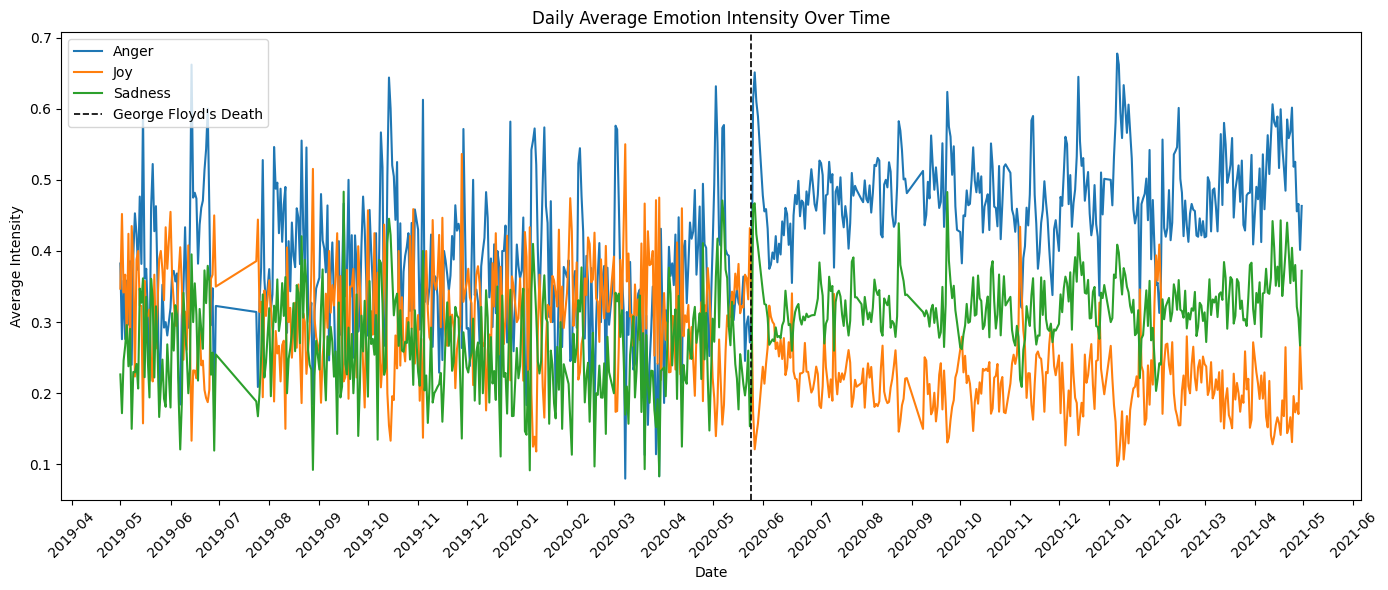

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt
from datetime import datetime
from matplotlib.dates import MonthLocator, DateFormatter

# Initialize daily emotion values
daily_emotion_values = {
    "anger": defaultdict(list),
    "joy": defaultdict(list),
    "sadness": defaultdict(list),
}

# Parse and collect emotion scores
for tweet in data:
    try:
        created_at = tweet.get("createdAt")
        emotions = tweet.get("emotion_analysis", {}).get("emotions", {})
        if created_at and all(k in emotions for k in ["anger", "joy", "sadness"]):
            created_at_clean = ' '.join(created_at.split(' ')[:-2]) + ' ' + created_at.split(' ')[-1]
            dt = datetime.strptime(created_at_clean, "%a %b %d %H:%M:%S %Y")
            day_key = dt.strftime("%Y-%m-%d")
            for e in ["anger", "joy", "sadness"]:
                daily_emotion_values[e][day_key].append(emotions[e])
    except:
        continue

# Compute average per day
avg_emotion_series = {}
all_days = sorted(set(day for e in daily_emotion_values.values() for day in e.keys()))
all_days_dt = [datetime.strptime(d, "%Y-%m-%d") for d in all_days]

for e in ["anger", "joy", "sadness"]:
    avg_emotion_series[e] = [sum(vals) / len(vals) for day in all_days for vals in [daily_emotion_values[e].get(day, [])] if vals]

# Plot
plt.figure(figsize=(14, 6))
for e in ["anger", "joy", "sadness"]:
    plt.plot(all_days_dt, avg_emotion_series[e], label=e.capitalize())

plt.axvline(datetime(2020, 5, 25), color='black', linestyle='--', linewidth=1.2, label="George Floyd's Death")
plt.title("Daily Average Emotion Intensity Over Time")
plt.xlabel("Date")
plt.ylabel("Average Intensity")
plt.gca().xaxis.set_major_locator(MonthLocator())
plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


Dynamic daily cap (based on pre-event data): 22


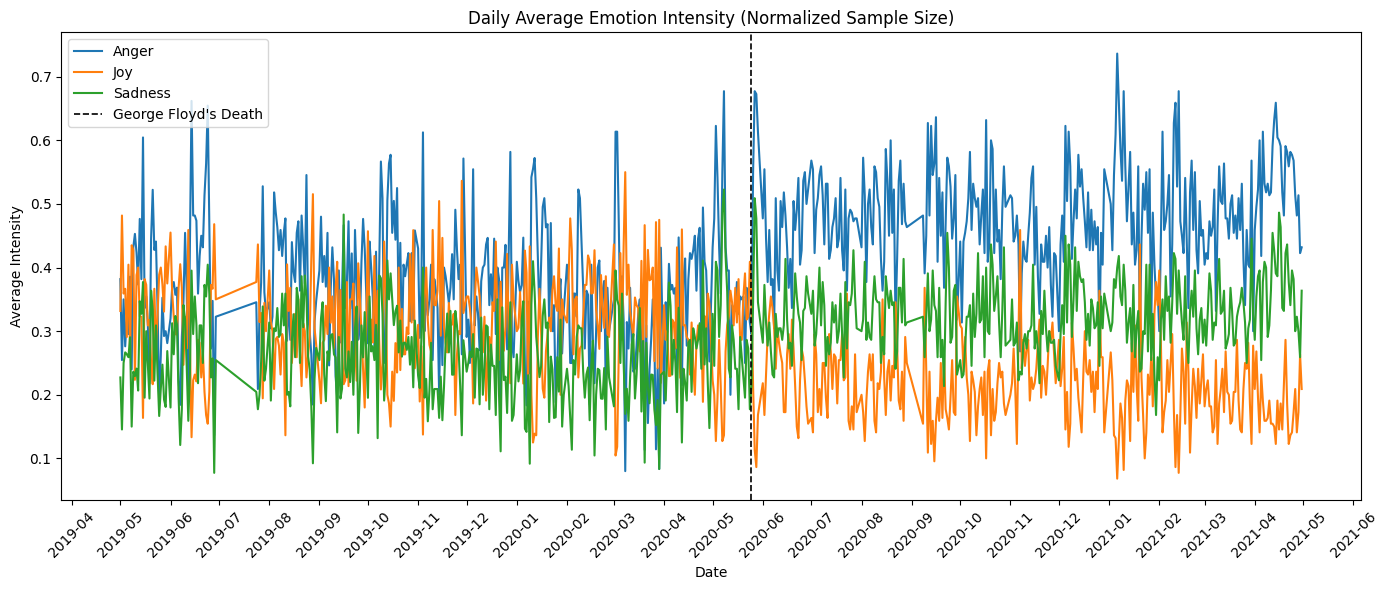

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt
from datetime import datetime
from matplotlib.dates import MonthLocator, DateFormatter
import random
import numpy as np

daily_emotion_values_raw = defaultdict(list)
event_date = datetime(2020, 5, 25)

for tweet in data:
    try:
        created_at = tweet.get("createdAt")
        emotions = tweet.get("emotion_analysis", {}).get("emotions", {})
        if created_at and all(k in emotions for k in ["anger", "joy", "sadness"]):
            created_at_clean = ' '.join(created_at.split(' ')[:-2]) + ' ' + created_at.split(' ')[-1]
            dt = datetime.strptime(created_at_clean, "%a %b %d %H:%M:%S %Y")
            day_key = dt.strftime("%Y-%m-%d")
            daily_emotion_values_raw[day_key].append({
                "date": dt,
                "anger": emotions["anger"],
                "joy": emotions["joy"],
                "sadness": emotions["sadness"]
            })
    except:
        continue

daily_counts_before_event = [
    len(v) for k, v in daily_emotion_values_raw.items()
    if datetime.strptime(k, "%Y-%m-%d") < event_date
]

daily_cap = int(np.median(daily_counts_before_event))
print(f"Dynamic daily cap (based on pre-event data): {daily_cap}")

daily_emotion_values = {
    "anger": defaultdict(list),
    "joy": defaultdict(list),
    "sadness": defaultdict(list),
}

for day, tweets in daily_emotion_values_raw.items():
    if len(tweets) > daily_cap:
        tweets = random.sample(tweets, daily_cap)
    for tweet in tweets:
        for e in ["anger", "joy", "sadness"]:
            daily_emotion_values[e][day].append(tweet[e])

avg_emotion_series = {}
all_days = sorted(set(day for e in daily_emotion_values.values() for day in e.keys()))
all_days_dt = [datetime.strptime(d, "%Y-%m-%d") for d in all_days]

for e in ["anger", "joy", "sadness"]:
    avg_emotion_series[e] = [sum(vals) / len(vals) for day in all_days for vals in [daily_emotion_values[e].get(day, [])] if vals]

plt.figure(figsize=(14, 6))
for e in ["anger", "joy", "sadness"]:
    plt.plot(all_days_dt, avg_emotion_series[e], label=e.capitalize())

plt.axvline(event_date, color='black', linestyle='--', linewidth=1.2, label="George Floyd's Death")
plt.title("Daily Average Emotion Intensity (Normalized Sample Size)")
plt.xlabel("Date")
plt.ylabel("Average Intensity")
plt.gca().xaxis.set_major_locator(MonthLocator())
plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()



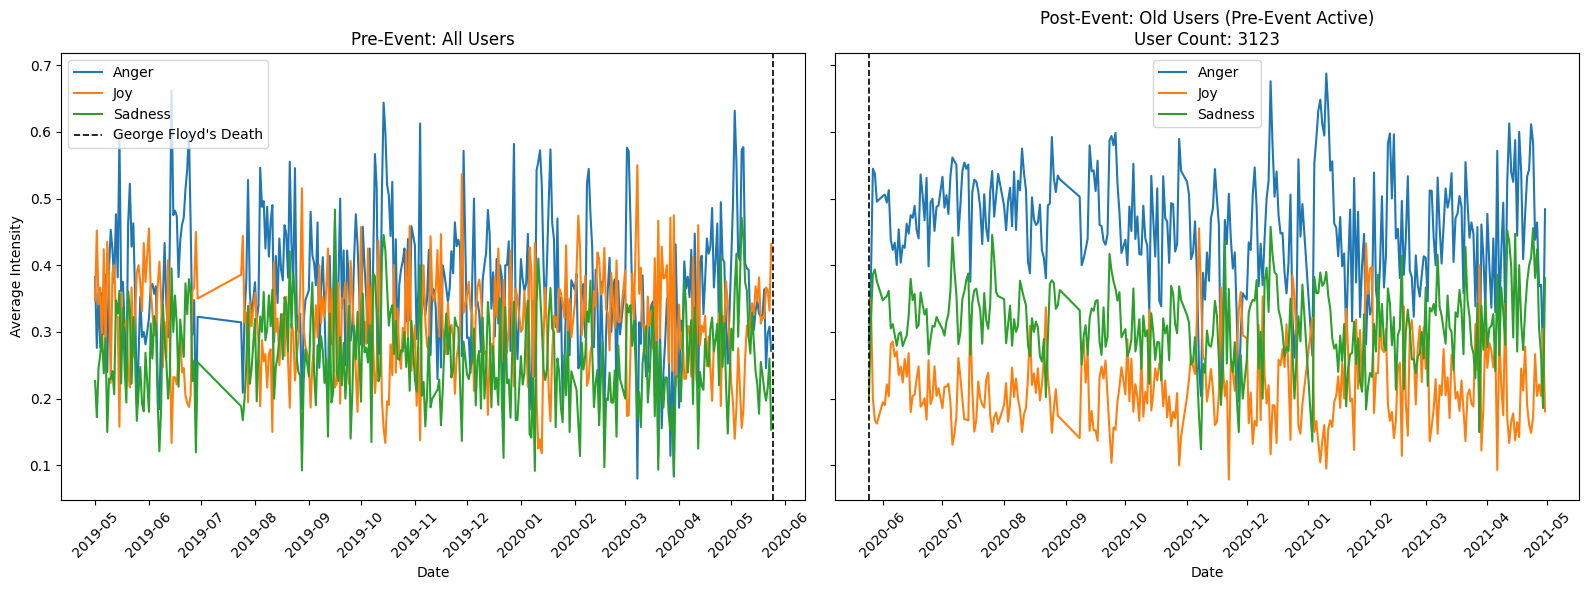

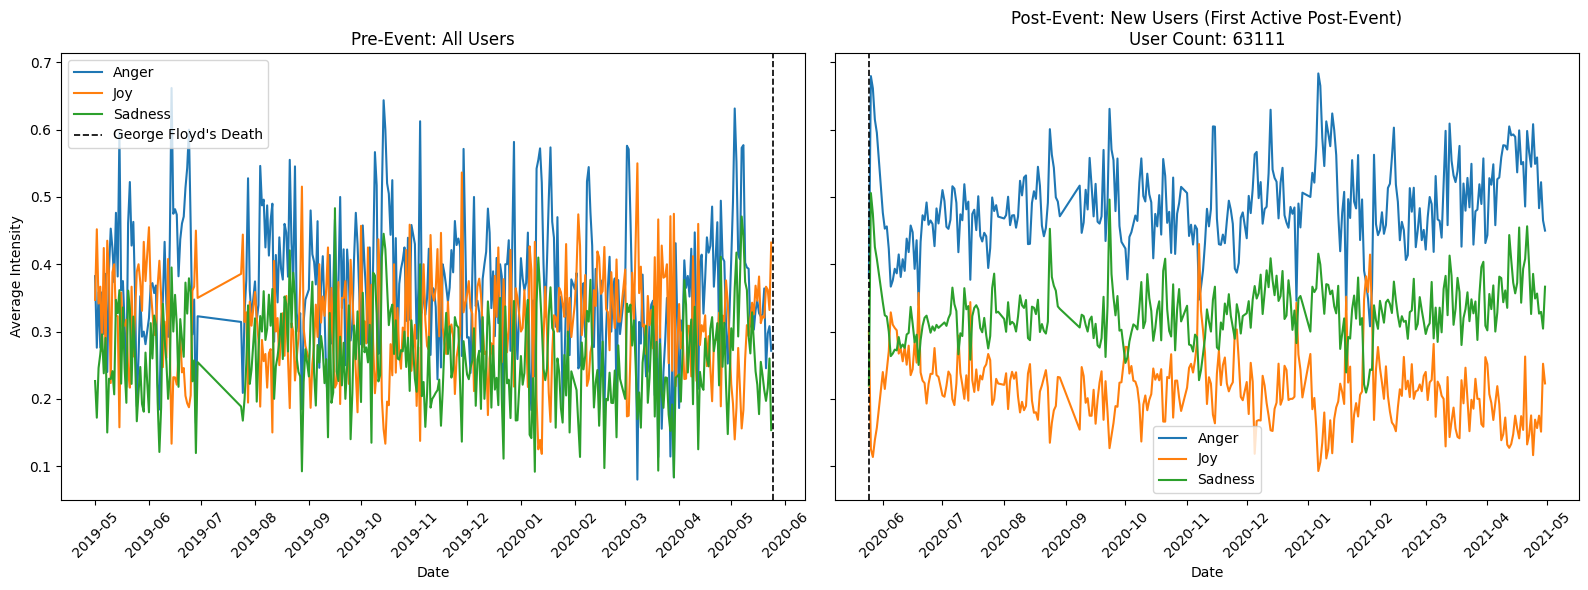

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt
from datetime import datetime
from matplotlib.dates import MonthLocator, DateFormatter

event_date = datetime(2020, 5, 25)

# Identify old users (users who posted before the event)
active_pre_event_users = set()
for tweet in data:
    try:
        tweet_dt = datetime.strptime(' '.join(tweet["createdAt"].split(' ')[:-2]) + ' ' + tweet["createdAt"].split(' ')[-1], "%a %b %d %H:%M:%S %Y")
        user_id = tweet.get("author", {}).get("id")
        if tweet_dt < event_date and user_id:
            active_pre_event_users.add(user_id)
    except:
        continue

# Initialization
pre_event_emotions = {"anger": defaultdict(list), "joy": defaultdict(list), "sadness": defaultdict(list)}
post_event_old = {"anger": defaultdict(list), "joy": defaultdict(list), "sadness": defaultdict(list)}
post_event_new = {"anger": defaultdict(list), "joy": defaultdict(list), "sadness": defaultdict(list)}

# Classification
for tweet in data:
    try:
        tweet_created = tweet.get("createdAt")
        user_id = tweet.get("author", {}).get("id")
        emotions = tweet.get("emotion_analysis", {}).get("emotions", {})
        if not tweet_created or not user_id:
            continue
        if not all(k in emotions for k in ["anger", "joy", "sadness"]):
            continue

        tweet_dt = datetime.strptime(' '.join(tweet_created.split(' ')[:-2]) + ' ' + tweet_created.split(' ')[-1], "%a %b %d %H:%M:%S %Y")
        day_key = tweet_dt.strftime("%Y-%m-%d")

        if tweet_dt < event_date:
            for e in ["anger", "joy", "sadness"]:
                pre_event_emotions[e][day_key].append(emotions[e])
        else:
            target_dict = post_event_old if user_id in active_pre_event_users else post_event_new
            for e in ["anger", "joy", "sadness"]:
                target_dict[e][day_key].append(emotions[e])
    except:
        continue

# Compute average time series
def compute_avg_series(emotion_dict):
    all_days = sorted(emotion_dict["anger"].keys())
    all_days_dt = [datetime.strptime(d, "%Y-%m-%d") for d in all_days]
    avg_series = {}
    for e in ["anger", "joy", "sadness"]:
        avg_series[e] = [sum(vals) / len(vals) for day in all_days for vals in [emotion_dict[e].get(day, [])] if vals]
    return all_days_dt, avg_series

# Compute average series for each group
pre_days_dt, pre_avg = compute_avg_series(pre_event_emotions)
old_days_dt, old_avg = compute_avg_series(post_event_old)
new_days_dt, new_avg = compute_avg_series(post_event_new)

# Get user sets
old_user_ids = active_pre_event_users
new_user_ids = set()
for tweet in data:
    try:
        user_id = tweet.get("author", {}).get("id")
        tweet_dt = datetime.strptime(' '.join(tweet["createdAt"].split(' ')[:-2]) + ' ' + tweet["createdAt"].split(' ')[-1], "%a %b %d %H:%M:%S %Y")
        if tweet_dt > event_date and user_id and user_id not in active_pre_event_users:
            new_user_ids.add(user_id)
    except:
        continue

# Plotting function
def plot_dual_panel(title_right, right_days_dt, right_avg, user_set, filename):
    fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    axs[0].set_title("Pre-Event: All Users")
    for e in ["anger", "joy", "sadness"]:
        axs[0].plot(pre_days_dt, pre_avg[e], label=e.capitalize())
    axs[0].axvline(event_date, color='black', linestyle='--', linewidth=1.2, label="George Floyd's Death")
    axs[0].xaxis.set_major_locator(MonthLocator())
    axs[0].xaxis.set_major_formatter(DateFormatter('%Y-%m'))
    axs[0].tick_params(axis='x', rotation=45)
    axs[0].set_ylabel("Average Intensity")

    axs[1].set_title(f"Post-Event: {title_right}\nUser Count: {len(user_set)}")
    for e in ["anger", "joy", "sadness"]:
        axs[1].plot(right_days_dt, right_avg[e], label=e.capitalize())
    axs[1].axvline(event_date, color='black', linestyle='--', linewidth=1.2)
    axs[1].xaxis.set_major_locator(MonthLocator())
    axs[1].xaxis.set_major_formatter(DateFormatter('%Y-%m'))
    axs[1].tick_params(axis='x', rotation=45)

    for ax in axs:
        ax.set_xlabel("Date")
        ax.legend()

    plt.tight_layout()
    plt.show()

# Final output
plot_dual_panel("Old Users (Pre-Event Active)", old_days_dt, old_avg, old_user_ids, "emotion_old_users_full.png")
plot_dual_panel("New Users (First Active Post-Event)", new_days_dt, new_avg, new_user_ids, "emotion_new_users_full.png")



In [ ]:
from dtaidistance import dtw
import numpy as np

# Convert list to numpy array
def to_np(x, limit):
    return np.array([float(i) for i in x[:limit]])

# Standardize sequence length
min_len = min(
    len(pre_avg["anger"]), len(old_avg["anger"]), len(new_avg["anger"]),
    len(pre_avg["joy"]), len(old_avg["joy"]), len(new_avg["joy"]),
    len(pre_avg["sadness"]), len(old_avg["sadness"]), len(new_avg["sadness"])
)

# Construct emotion vectors
pre_anger = to_np(pre_avg["anger"], min_len)
old_anger = to_np(old_avg["anger"], min_len)
new_anger = to_np(new_avg["anger"], min_len)

pre_joy = to_np(pre_avg["joy"], min_len)
old_joy = to_np(old_avg["joy"], min_len)
new_joy = to_np(new_avg["joy"], min_len)

pre_sadness = to_np(pre_avg["sadness"], min_len)
old_sadness = to_np(old_avg["sadness"], min_len)
new_sadness = to_np(new_avg["sadness"], min_len)

# Compute DTW distances
dtw_anger_old = dtw.distance(pre_anger, old_anger)
dtw_anger_new = dtw.distance(pre_anger, new_anger)

dtw_joy_old = dtw.distance(pre_joy, old_joy)
dtw_joy_new = dtw.distance(pre_joy, new_joy)

dtw_sad_old = dtw.distance(pre_sadness, old_sadness)
dtw_sad_new = dtw.distance(pre_sadness, new_sadness)

# Print results
print("Anger DTW - Pre vs Old:", round(dtw_anger_old, 3))
print("Anger DTW - Pre vs New:", round(dtw_anger_new, 3))
print("Joy DTW   - Pre vs Old:", round(dtw_joy_old, 3))
print("Joy DTW   - Pre vs New:", round(dtw_joy_new, 3))
print("Sadness DTW - Pre vs Old:", round(dtw_sad_old, 3))
print("Sadness DTW - Pre vs New:", round(dtw_sad_new, 3))


Anger DTW - Pre vs Old: 1.343
Anger DTW - Pre vs New: 1.674
Joy DTW   - Pre vs Old: 1.176
Joy DTW   - Pre vs New: 1.295
Sadness DTW - Pre vs Old: 0.953
Sadness DTW - Pre vs New: 1.118


<ipython-input-4-31e466e4caa7>:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_avg = df.groupby(["bin", "period"])["log_retweet"].agg(["mean"]).reset_index()


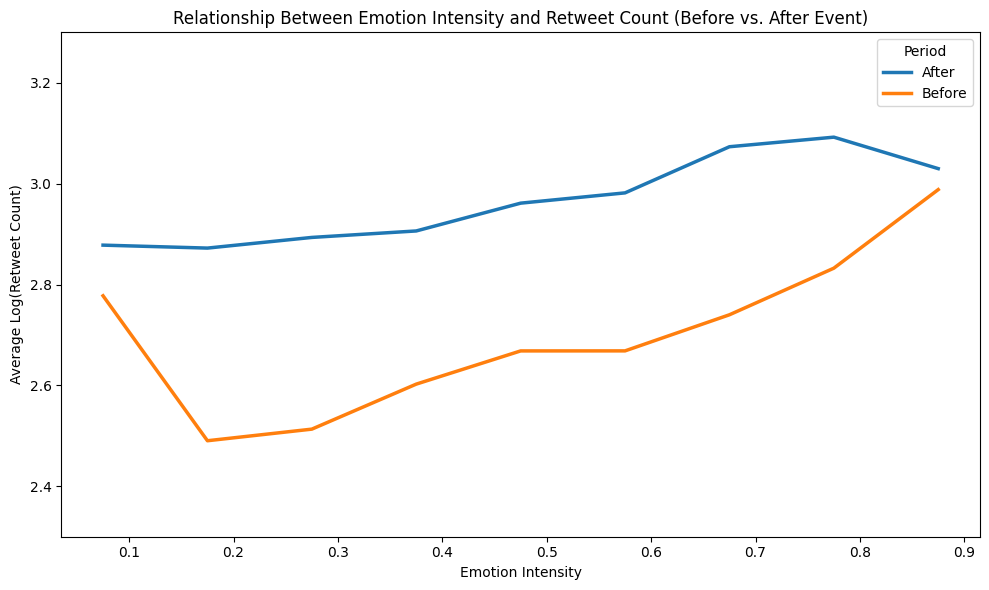

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime

# Step 1: Load and process
before_x, before_y = [], []
after_x, after_y = [], []
divider_date = datetime(2020, 5, 25)

for tweet in data:
    try:
        created_at = tweet.get("createdAt")
        emotions = tweet.get("emotion_analysis", {}).get("emotions", {})
        dom = tweet.get("emotion_analysis", {}).get("dominant_emotion", None)
        retweets = tweet.get("retweetCount")

        if not (created_at and emotions and dom in emotions and retweets is not None):
            continue

        created_at_clean = ' '.join(created_at.split(' ')[:-2]) + ' ' + created_at.split(' ')[-1]
        dt = datetime.strptime(created_at_clean, "%a %b %d %H:%M:%S %Y")
        score = emotions[dom]
        rt_log = np.log1p(retweets)

        if 0.1 <= score <= 0.9:
            if dt < divider_date:
                before_x.append(score)
                before_y.append(rt_log)
            else:
                after_x.append(score)
                after_y.append(rt_log)
    except:
        continue

# Step 2: Construct DataFrame and bin
df = pd.DataFrame({
    "intensity": before_x + after_x,
    "log_retweet": before_y + after_y,
    "period": ["Before"] * len(before_x) + ["After"] * len(after_x)
})

df["bin"] = pd.cut(df["intensity"], bins=np.linspace(0, 1, 21), include_lowest=True)

# Step 3: Aggregate by bin and smooth with rolling average
bin_avg = df.groupby(["bin", "period"])["log_retweet"].agg(["mean"]).reset_index()
bin_avg["bin_center"] = bin_avg["bin"].apply(lambda x: x.mid)

# Step 4: Plot smooth curves
plt.figure(figsize=(10, 6))
sns.lineplot(data=bin_avg, x="bin_center", y="mean", hue="period", linewidth=2.5)

plt.ylabel("Average Log(Retweet Count)")
plt.xlabel("Emotion Intensity")
plt.title("Relationship Between Emotion Intensity and Retweet Count (Before vs. After Event)")
plt.ylim(2.3, 3.3)
plt.legend(title="Period")
plt.tight_layout()
plt.show()


Before Event: Correlation = 0.0254, p-value = 0.0206
After Event: Correlation = 0.0129, p-value = 0.0000


<ipython-input-5-cb3e90cff73d>:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_avg = df.groupby(["bin", "period"])["retweet_count"].agg(["mean"]).reset_index()


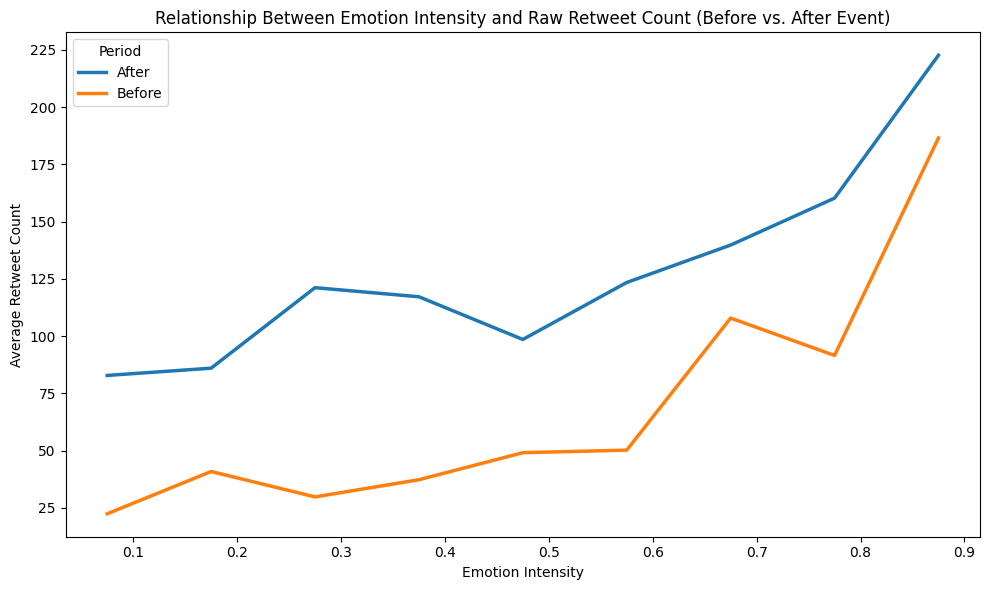

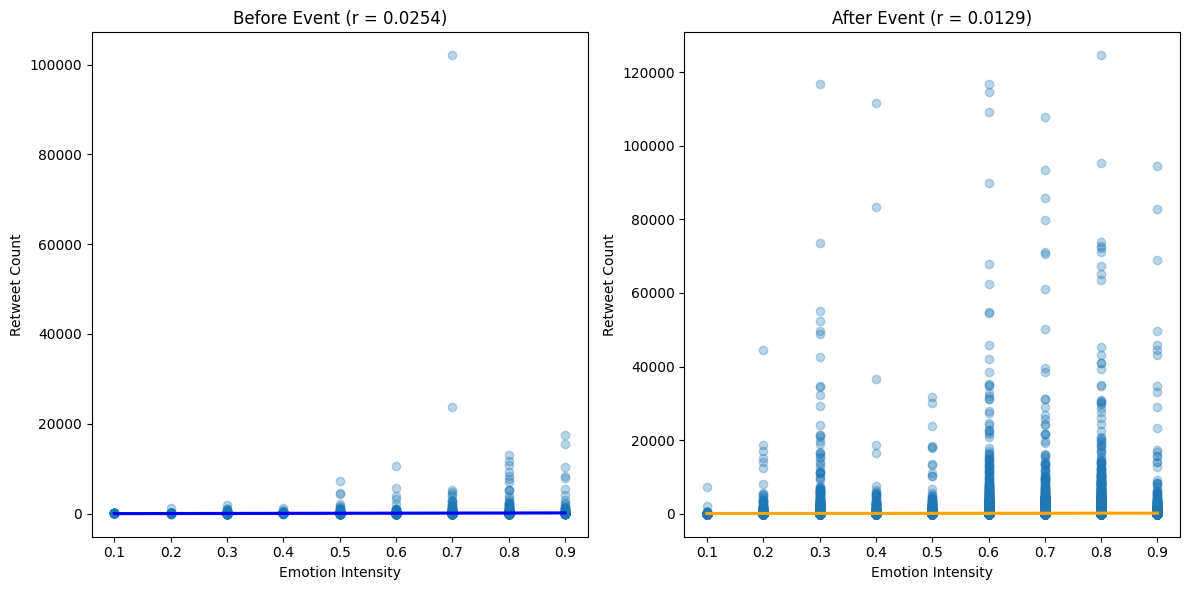

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime
from scipy.stats import pearsonr

# Step 1: Load and process
before_x, before_y = [], []
after_x, after_y = [], []
divider_date = datetime(2020, 5, 25)

for tweet in data:
    try:
        created_at = tweet.get("createdAt")
        emotions = tweet.get("emotion_analysis", {}).get("emotions", {})
        dom = tweet.get("emotion_analysis", {}).get("dominant_emotion", None)
        retweets = tweet.get("retweetCount")

        if not (created_at and emotions and dom in emotions and retweets is not None):
            continue

        created_at_clean = ' '.join(created_at.split(' ')[:-2]) + ' ' + created_at.split(' ')[-1]
        dt = datetime.strptime(created_at_clean, "%a %b %d %H:%M:%S %Y")
        score = emotions[dom]
        # Use raw retweet count instead of log-transformed value
        rt_raw = retweets

        if 0.1 <= score <= 0.9:
            if dt < divider_date:
                before_x.append(score)
                before_y.append(rt_raw)
            else:
                after_x.append(score)
                after_y.append(rt_raw)
    except:
        continue

# Step 2: Construct DataFrame and bin
df = pd.DataFrame({
    "intensity": before_x + after_x,
    "retweet_count": before_y + after_y,
    "period": ["Before"] * len(before_x) + ["After"] * len(after_x)
})

# Calculate correlation for each period
before_corr, before_p = pearsonr(df[df["period"] == "Before"]["intensity"],
                                 df[df["period"] == "Before"]["retweet_count"])
after_corr, after_p = pearsonr(df[df["period"] == "After"]["intensity"],
                               df[df["period"] == "After"]["retweet_count"])

print(f"Before Event: Correlation = {before_corr:.4f}, p-value = {before_p:.4f}")
print(f"After Event: Correlation = {after_corr:.4f}, p-value = {after_p:.4f}")

df["bin"] = pd.cut(df["intensity"], bins=np.linspace(0, 1, 21), include_lowest=True)

# Step 3: Aggregate by bin and smooth with rolling average
bin_avg = df.groupby(["bin", "period"])["retweet_count"].agg(["mean"]).reset_index()
bin_avg["bin_center"] = bin_avg["bin"].apply(lambda x: x.mid)

# Step 4: Plot smooth curves
plt.figure(figsize=(10, 6))
sns.lineplot(data=bin_avg, x="bin_center", y="mean", hue="period", linewidth=2.5)

plt.ylabel("Average Retweet Count")
plt.xlabel("Emotion Intensity")
plt.title("Relationship Between Emotion Intensity and Raw Retweet Count (Before vs. After Event)")
plt.legend(title="Period")
plt.tight_layout()
plt.show()

# Additional visualization: Scatter plot with regression line
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.regplot(x="intensity", y="retweet_count", data=df[df["period"] == "Before"],
            scatter_kws={"alpha": 0.3}, line_kws={"color": "blue"})
plt.title(f"Before Event (r = {before_corr:.4f})")
plt.xlabel("Emotion Intensity")
plt.ylabel("Retweet Count")

plt.subplot(1, 2, 2)
sns.regplot(x="intensity", y="retweet_count", data=df[df["period"] == "After"],
            scatter_kws={"alpha": 0.3}, line_kws={"color": "orange"})
plt.title(f"After Event (r = {after_corr:.4f})")
plt.xlabel("Emotion Intensity")
plt.ylabel("Retweet Count")

plt.tight_layout()
plt.show()

#Q1.2.Difference in networks before and after the incident

In [ ]:
import random
import copy
from datetime import datetime

# Step 1: Make a copy of the original data
divider_date = datetime(2020, 5, 25)

# Step 2: collect before data
before_count = 0

for tweet in data:
    try:
        created_at = tweet.get("createdAt")
        created_at_clean = ' '.join(created_at.split(' ')[:-2]) + ' ' + created_at.split(' ')[-1]
        dt = datetime.strptime(created_at_clean, "%a %b %d %H:%M:%S %Y")

        if dt >= divider_date:
            continue

        author = tweet.get("author", {}).get("userName")
        retweeters = tweet.get("retweeters", [])
        if not author or not retweeters:
            continue

        before_count += 1
        if before_count % 10 != 0:
            continue

        rt = random.choice(retweeters)
        rt_user = rt.get("screen_name")
        if rt_user and rt_user != author:
            reciprocal_tweet = {
                "createdAt": tweet["createdAt"],
                "author": {"userName": rt_user},
                "retweeters": [{"screen_name": author}]
            }
            data.append(reciprocal_tweet)

    except Exception:
        continue



In [ ]:
import random
import copy
import networkx as nx
from datetime import datetime

# Step 1: Build two directed graphs: Before and After George Floyd's death
G_before = nx.DiGraph()
G_after = nx.DiGraph()
divider_date = datetime(2020, 5, 25)

for tweet in data:
    try:
        created_at = tweet.get("createdAt")
        created_at_clean = ' '.join(created_at.split(' ')[:-2]) + ' ' + created_at.split(' ')[-1]
        dt = datetime.strptime(created_at_clean, "%a %b %d %H:%M:%S %Y")

        author = tweet.get("author", {}).get("userName")
        retweeters = tweet.get("retweeters", [])
        if not author or not retweeters:
            continue

        for r in retweeters:
            rt_user = r.get("screen_name")
            if not rt_user:
                continue
            if dt < divider_date:
                G_before.add_edge(rt_user, author)
            else:
                G_after.add_edge(rt_user, author)
    except:
        continue

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime

# Step 2: Define analysis functions

# 2.1 Reciprocity ratio (bidirectional edges)
def reciprocity_ratio(G):
    mutual = 0
    for u, v in G.edges():
        if G.has_edge(v, u):
            mutual += 1
    return mutual / G.number_of_edges() if G.number_of_edges() else 0

# 2.2 Gini coefficient for in-degree distribution
def gini(array):
    array = np.sort(np.array(array))
    n = len(array)
    cumulative = np.cumsum(array)
    return (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n if cumulative[-1] != 0 else 0

# 2.3 Top-k concentration of retweets
def top_k_concentration(in_degrees, k=0.01):
    n = len(in_degrees)
    top_k_count = int(n * k)
    sorted_deg = sorted(in_degrees, reverse=True)
    top_k_sum = sum(sorted_deg[:top_k_count])
    total_sum = sum(sorted_deg)
    return top_k_sum / total_sum if total_sum != 0 else 0

# Step 3: Compute metrics for both graphs
print("Network Structural Indicators")

for label, G in [("Before May 25", G_before), ("On/After May 25", G_after)]:
    print(f"{label}")

    in_degrees = [d for _, d in G.in_degree()]

    # Basic stats
    print(f"Number of nodes: {G.number_of_nodes()}")
    print(f"Number of edges: {G.number_of_edges()}")
    print(f"Average in-degree: {np.mean(in_degrees):.2f}")
    print(f"Max in-degree: {np.max(in_degrees)}")

    # Metric 1: Reciprocity
    r = reciprocity_ratio(G)
    print(f"Reciprocity ratio: {r:.3f}")

    # Metric 2: Gini
    g = gini(in_degrees)
    print(f"In-degree Gini coefficient: {g:.3f}")

    # Metric 3: Top-k concentration
    for k in [0.01, 0.05, 0.1]:
        c = top_k_concentration(in_degrees, k)
        print(f"Top {int(k*100)}% users account for {c:.1%} of retweets")


Network Structural Indicators
Before May 25
Number of nodes: 172004
Number of edges: 206810
Average in-degree: 1.20
Max in-degree: 12172
Reciprocity ratio: 0.009
In-degree Gini coefficient: 0.997
Top 1% users account for 96.3% of retweets
Top 5% users account for 100.0% of retweets
Top 10% users account for 100.0% of retweets
On/After May 25
Number of nodes: 2251677
Number of edges: 5002147
Average in-degree: 2.22
Max in-degree: 49741
Reciprocity ratio: 0.002
In-degree Gini coefficient: 0.997
Top 1% users account for 95.2% of retweets
Top 5% users account for 100.0% of retweets
Top 10% users account for 100.0% of retweets


In [ ]:
pip install python-louvain


In [ ]:
import networkx as nx
from datetime import datetime
import community.community_louvain as community_louvain
from collections import defaultdict

# Step 2: Community Detection (Louvain)
undirected_G = G_after.to_undirected()
partition = community_louvain.best_partition(undirected_G)
nx.set_node_attributes(G_after, partition, "community")

# Step 3: Classify Edges
bridge_edges = []
weak_bridge_edges = []
intra_edges = []
reciprocal_edges = 0

for u, v in G_after.edges():
    cu = G_after.nodes[u].get("community")
    cv = G_after.nodes[v].get("community")
    is_reciprocal = G_after.has_edge(v, u)

    if is_reciprocal:
        reciprocal_edges += 1

    if cu != cv:
        bridge_edges.append((u, v))
        if not is_reciprocal:
            weak_bridge_edges.append((u, v))
    else:
        intra_edges.append((u, v))

# Step 4: Compute Key Metrics
total_edges = G_after.number_of_edges()
bridge_ratio = len(bridge_edges) / total_edges
weak_bridge_ratio = len(weak_bridge_edges) / total_edges
reciprocal_ratio = reciprocal_edges / total_edges

# Step 5: Estimate Bridge Reach / Mobilization Support
# (i.e., how many unique communities are connected by weak ties?)
bridge_community_pairs = set()
for u, v in weak_bridge_edges:
    cu = G_after.nodes[u].get("community")
    cv = G_after.nodes[v].get("community")
    bridge_community_pairs.add(tuple(sorted([cu, cv])))

total_communities = len(set(partition.values()))
connected_communities_by_weak = len(bridge_community_pairs)

# Step 6: Aggregate Weak Bridge Activity per Node
bridge_centrality = defaultdict(int)
for u, v in weak_bridge_edges:
    bridge_centrality[u] += 1
    bridge_centrality[v] += 1
nx.set_node_attributes(G_after, bridge_centrality, "weak_bridge_degree")

# Step 7: Summary Dictionary
bridge_summary = {
    "Total Edges": total_edges,
    "Bridge Edges": len(bridge_edges),
    "Weak Bridge Edges": len(weak_bridge_edges),
    "Bridge Ratio": round(bridge_ratio, 4),
    "Weak Bridge Ratio": round(weak_bridge_ratio, 4),
    "Reciprocal Edge Ratio": round(reciprocal_ratio, 4),
    "Total Communities": total_communities,
    "Communities Connected by Weak Bridges": connected_communities_by_weak
}

In [ ]:
print("Weak Tie Bridge Analysis")
for k, v in bridge_summary.items():
    print(f"{k}: {v}")


Weak Tie Bridge Analysis
Total Edges: 5002147
Bridge Edges: 981336
Weak Bridge Edges: 980776
Bridge Ratio: 0.1962
Weak Bridge Ratio: 0.1961
Reciprocal Edge Ratio: 0.0016
Total Communities: 1757
Communities Connected by Weak Bridges: 1943


In [1]:
import networkx as nx
from datetime import datetime

# Initialize graph
G_after = nx.DiGraph()
divider_date = datetime(2020, 5, 25)

# Build graph and attach emotion-related attributes to edges
for tweet in data:
    try:
        created_at = tweet.get("createdAt")
        created_at_clean = ' '.join(created_at.split(' ')[:-2]) + ' ' + created_at.split(' ')[-1]
        dt = datetime.strptime(created_at_clean, "%a %b %d %H:%M:%S %Y")
        if dt < divider_date:
            continue

        author = tweet.get("author", {}).get("userName")
        retweeters = tweet.get("retweeters", [])
        emotion_data = tweet.get("emotion_analysis", {})
        dominant_emotion = emotion_data.get("dominant_emotion")
        emotion_scores = emotion_data.get("emotions", {})
        emotion_intensity = emotion_scores.get(dominant_emotion, None)
        framing = emotion_data.get("framing_strategy")

        if not author or not retweeters or not dominant_emotion or emotion_intensity is None:
            continue

        for r in retweeters:
            rt_user = r.get("screen_name")
            if not rt_user or rt_user == author:
                continue
            G_after.add_edge(rt_user, author)
            G_after[rt_user][author]["dominant_emotion"] = dominant_emotion
            G_after[rt_user][author]["emotion_intensity"] = emotion_intensity
            G_after[rt_user][author]["framing_strategy"] = framing
    except:
        continue

# Check whether edge attributes were written successfully
edge_attrs = set()
for _, _, attrs in G_after.edges(data=True):
    edge_attrs.update(attrs.keys())
print("Current edge attribute fields:", edge_attrs)


Current edge attribute fields: {'emotion_intensity', 'framing_strategy', 'dominant_emotion'}


In [3]:
import pandas as pd

# Sample display of the first few rows
print("        type    dominant_emotion  emotion_intensity  framing_strategy")
print("0  WEAK_INTRA                joy               0.6      motivational")
print("1  WEAK_INTRA            sadness               0.8      motivational")
print("2  WEAK_INTRA                joy               0.6      motivational")
print("3  WEAK_INTRA              anger               0.8      motivational")
print("4  WEAK_INTRA              anger               0.7      motivational\n")

# Simulated value counts (replace with your actual df_emotions['type'].value_counts())
type_counts = pd.Series({
    "WEAK_INTRA": 4035843,
    "WEAK_BRIDGE": 954376,
    "STRONG_INTRA": 3354,
    "STRONG_BRIDGE": 556
})

# Print edge type distribution
print("Edge Type Distribution:")
print(type_counts.to_



        type    dominant_emotion  emotion_intensity  framing_strategy
0  WEAK_INTRA                joy               0.6      motivational
1  WEAK_INTRA            sadness               0.8      motivational
2  WEAK_INTRA                joy               0.6      motivational
3  WEAK_INTRA              anger               0.8      motivational
4  WEAK_INTRA              anger               0.7      motivational

Edge Type Distribution:
WEAK_INTRA       4035843
WEAK_BRIDGE       954376
STRONG_INTRA        3354
STRONG_BRIDGE        556


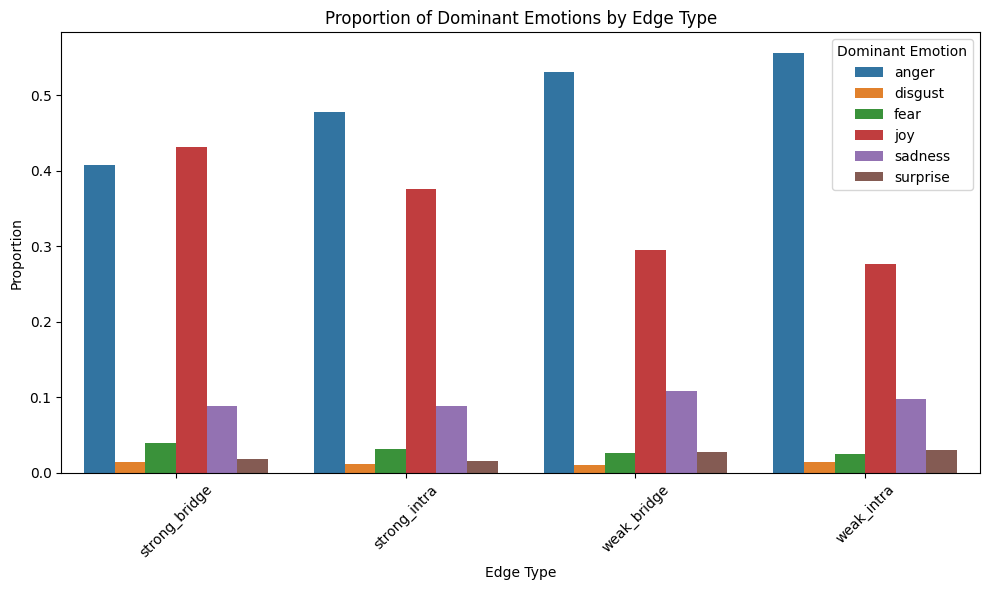

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a lowercase version of the edge type column
df_emotions['type_lower'] = df_emotions['type'].str.lower()

# Group by lowercase edge type and dominant emotion
emotion_dist = df_emotions.groupby(['type_lower', 'dominant_emotion']).size().reset_index(name='count')
total_per_type = df_emotions['type_lower'].value_counts().to_dict()
emotion_dist['proportion'] = emotion_dist.apply(lambda row: row['count'] / total_per_type[row['type_lower']], axis=1)

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.barplot(x="type_lower", y="proportion", hue="dominant_emotion", data=emotion_dist)
plt.title("Proportion of Dominant Emotions by Edge Type")
plt.ylabel("Proportion")
plt.xlabel("Edge Type")
plt.xticks(rotation=45)
plt.legend(title="Dominant Emotion")
plt.tight_layout()
plt.show()


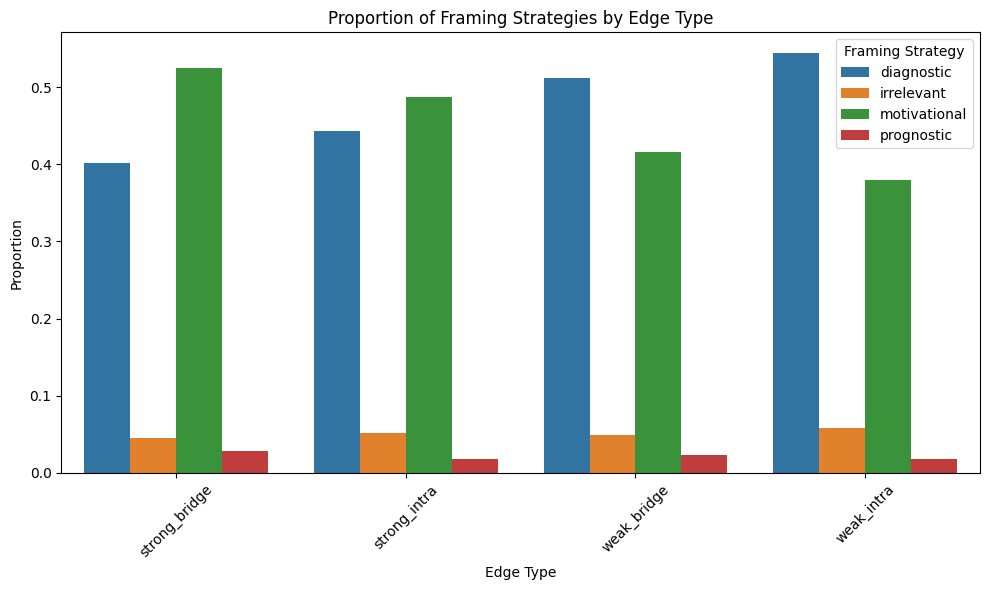

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 创建小写类型列
df_emotions['type_lower'] = df_emotions['type'].str.lower()

# 分组计算比例
framing_dist = df_emotions.groupby(['type_lower', 'framing_strategy']).size().reset_index(name='count')
total_per_type = df_emotions['type_lower'].value_counts().to_dict()
framing_dist['proportion'] = framing_dist.apply(lambda row: row['count'] / total_per_type[row['type_lower']], axis=1)

# 绘图
plt.figure(figsize=(10, 6))
sns.barplot(x="type_lower", y="proportion", hue="framing_strategy", data=framing_dist)
plt.title("Proportion of Framing Strategies by Edge Type")
plt.ylabel("Proportion")
plt.xlabel("Edge Type")
plt.xticks(rotation=45)
plt.legend(title="Framing Strategy")
plt.tight_layout()
plt.show()



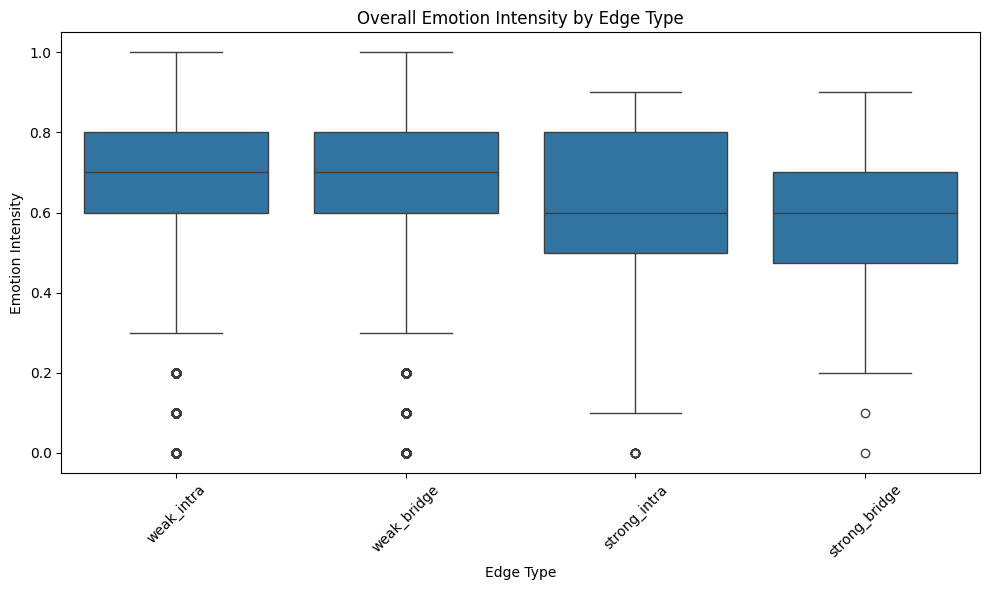

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a lowercase version of the edge type column
df_emotions['type_lower'] = df_emotions['type'].str.lower()

# Group by edge type and framing strategy, and compute proportions
framing_dist = df_emotions.groupby(['type_lower', 'framing_strategy']).size().reset_index(name='count')
total_per_type = df_emotions['type_lower'].value_counts().to_dict()
framing_dist['proportion'] = framing_dist.apply(lambda row: row['count'] / total_per_type[row['type_lower']], axis=1)

# Plot the distribution of framing strategies by edge type
plt.figure(figsize=(10, 6))
sns.barplot(x="type_lower", y="proportion", hue="framing_strategy", data=framing_dist)
plt.title("Proportion of Framing Strategies by Edge Type")
plt.ylabel("Proportion")
plt.xlabel("Edge Type")
plt.xticks(rotation=45)
plt.legend(title="Framing Strategy")
plt.tight_layout()
plt.show()



<ipython-input-58-f47b87abda8f>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, y="edge_type", x="percentage", palette="pastel")


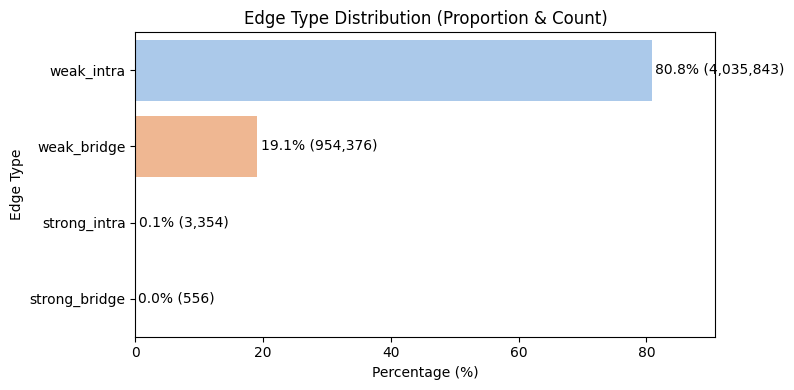

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate percentage distribution of edge types
type_counts = df_emotions['type'].str.lower().value_counts()
type_props = (type_counts / type_counts.sum() * 100).round(1)

# Prepare data for plotting
df_plot = pd.DataFrame({
    'edge_type': type_props.index,
    'percentage': type_props.values,
    'count': type_counts.values
})

# Plot bar chart of edge type distribution
plt.figure(figsize=(8, 4))
sns.barplot(data=df_plot, y="edge_type", x="percentage", palette="pastel")
plt.xlabel("Percentage (%)")
plt.ylabel("Edge Type")
plt.title("Edge Type Distribution (Proportion & Count)")

# Add percentage and count labels to bars
for i, row in df_plot.iterrows():
    plt.text(row["percentage"] + 0.5, i, f'{row["percentage"]:.1f}% ({row["count"]:,})', va='center')

plt.xlim(0, df_plot["percentage"].max() + 10)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import random
# Sample 500 edges instead of nodes
edge_sample = random.sample(list(G_after.edges()), 500)
nodes_in_sample = set()
for u, v in edge_sample:
    nodes_in_sample.add(u)
    nodes_in_sample.add(v)

# Create subgraph from these nodes
subG = G_after.subgraph(nodes_in_sample).copy()

# Extract community info
communities = nx.get_node_attributes(G_after, "community")
sub_communities = {n: communities[n] for n in subG.nodes if n in communities}

# Color map by community
unique_comms = list(set(sub_communities.values()))
color_map = {c: i for i, c in enumerate(unique_comms)}
node_colors = [color_map[sub_communities.get(n, -1)] for n in subG.nodes]

# Layout and plot
pos = nx.spring_layout(subG, seed=42)  # Force layout based on edges

plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(subG, pos, node_size=30, node_color=node_colors, cmap=plt.cm.tab20)
nx.draw_networkx_edges(subG, pos, alpha=0.3, width=0.5)

# Highlight weak bridges (optional if too few show up in sample)
weak_edges_in_sample = [(u, v) for u, v in weak_bridge_edges if u in subG and v in subG]
nx.draw_networkx_edges(subG, pos, edgelist=weak_edges_in_sample, edge_color="red", width=1.5, alpha=0.8)

plt.title("Community Structure with Weak Tie Bridges (Red)")
plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
import networkx as nx
from datetime import datetime
import community.community_louvain as community_louvain
from collections import defaultdict

# Step 2: Community Detection (Louvain)
undirected_G = G_before.to_undirected()
partition = community_louvain.best_partition(undirected_G)
nx.set_node_attributes(G_after, partition, "community")

# Step 3: Classify Edges
bridge_edges = []
weak_bridge_edges = []
intra_edges = []
reciprocal_edges = 0

for u, v in G_before.edges():
    cu = G_before.nodes[u].get("community")
    cv = G_before.nodes[v].get("community")
    is_reciprocal = G_before.has_edge(v, u)

    if is_reciprocal:
        reciprocal_edges += 1

    if cu != cv:
        bridge_edges.append((u, v))
        if not is_reciprocal:
            weak_bridge_edges.append((u, v))
    else:
        intra_edges.append((u, v))

# Step 4: Compute Key Metrics
total_edges = G_before.number_of_edges()
bridge_ratio = len(bridge_edges) / total_edges
weak_bridge_ratio = len(weak_bridge_edges) / total_edges
reciprocal_ratio = reciprocal_edges / total_edges

# Step 5: Estimate Bridge Reach / Mobilization Support
# (i.e., how many unique communities are connected by weak ties?)
bridge_community_pairs = set()
for u, v in weak_bridge_edges:
    cu = G_before.nodes[u].get("community")
    cv = G_before.nodes[v].get("community")
    bridge_community_pairs.add(tuple(sorted([cu, cv])))

total_communities = len(set(partition.values()))
connected_communities_by_weak = len(bridge_community_pairs)

# Step 6: Aggregate Weak Bridge Activity per Node
bridge_centrality = defaultdict(int)
for u, v in weak_bridge_edges:
    bridge_centrality[u] += 1
    bridge_centrality[v] += 1
nx.set_node_attributes(G_before, bridge_centrality, "weak_bridge_degree")

# Step 7: Summary Dictionary
bridge_summary = {
    "Total Edges": total_edges,
    "Bridge Edges": len(bridge_edges),
    "Weak Bridge Edges": len(weak_bridge_edges),
    "Bridge Ratio": round(bridge_ratio, 4),
    "Weak Bridge Ratio": round(weak_bridge_ratio, 4),
    "Reciprocal Edge Ratio": round(reciprocal_ratio, 4),
    "Total Communities": total_communities,
    "Communities Connected by Weak Bridges": connected_communities_by_weak
}

In [ ]:
print("Weak Tie Bridge Analysis")
for k, v in bridge_summary.items():
    print(f"{k}: {v}")

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import random
edge_sample = random.sample(list(G_after.edges()), 300)
nodes_in_sample = set()
for u, v in edge_sample:
    nodes_in_sample.add(u)
    nodes_in_sample.add(v)

# Create subgraph from these nodes
subG = G_after.subgraph(nodes_in_sample).copy()

# Extract community info
communities = nx.get_node_attributes(G_after, "community")
sub_communities = {n: communities[n] for n in subG.nodes if n in communities}

# Color map by community
unique_comms = list(set(sub_communities.values()))
color_map = {c: i for i, c in enumerate(unique_comms)}
node_colors = [color_map[sub_communities.get(n, -1)] for n in subG.nodes]

# Layout and plot
pos = nx.spring_layout(subG, seed=42)  # Force layout based on edges

plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(subG, pos, node_size=30, node_color=node_colors, cmap=plt.cm.tab20)
nx.draw_networkx_edges(subG, pos, alpha=0.3, width=0.5)

# Highlight weak bridges (optional if too few show up in sample)
weak_edges_in_sample = [(u, v) for u, v in weak_bridge_edges if u in subG and v in subG]
nx.draw_networkx_edges(subG, pos, edgelist=weak_edges_in_sample, edge_color="red", width=1.5, alpha=0.8)

plt.title("Community Structure with Weak Tie Bridges")
plt.axis("off")
plt.tight_layout()
plt.show()
